# FinTrust Banking Analytics
## Week 2 — Python Exploratory Data Analysis

**Project:** FinTrust Banking Analytics  
**Track:** Data Analytics  
**Week:** 2  

### Objective
This notebook performs exploratory data analysis (EDA) on FinTrust's customer and transaction datasets to identify meaningful patterns in customer segments, transaction types, transaction amounts, transaction channels, transaction status, international transactions, customer behaviour, and risk-review activity.

The analysis uses Python, Pandas, NumPy, Matplotlib, and Seaborn to generate descriptive statistics, visualizations, and business insights.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("Python environment is ready.")

Pandas version: 2.2.2
NumPy version: 1.26.4
Python environment is ready.


In [2]:
# Load FinTrust datasets

customer_file = "../data/raw/FinTrust_Customer_Data.csv"
transaction_file = "../data/processed/FinTrust_Transaction_Data_Cleaned.csv"

customers = pd.read_csv(customer_file)
transactions = pd.read_csv(transaction_file)

print("Customer dataset shape:", customers.shape)
print("Transaction dataset shape:", transactions.shape)

Customer dataset shape: (1500, 12)
Transaction dataset shape: (12000, 11)


## 1. Data Overview

This section examines the structure, columns, data types, and sample records in the customer and transaction datasets before exploratory analysis.

In [3]:
# Preview customer dataset
customers.head()

,Customer_ID,Customer_Name,Age,Gender,City,Customer_Segment,Account_Type,Tenure_Months,Digital_Engagement_Score,Monthly_Income_Band,Preferred_Channel,Account_Status
0,FT-C00001,Ibrahim Adeyemi,56,Male,Lagos,Premium,Savings,55,84.9,500k-999k,Mobile App,Active
1,FT-C00002,Yusuf Mohammed,46,Male,Kano,Everyday,Current,79,50.7,500k-999k,Mobile App,Active
2,FT-C00003,Emeka Adeyemi,32,Female,Port Harcourt,Everyday,Savings,43,56.1,1m+,Mobile App,Active
3,FT-C00004,David Williams,60,Female,Benin City,Premium,Premium,44,54.0,500k-999k,Mobile App,Dormant
4,FT-C00005,Blessing Adeyemi,25,Male,Kaduna,Premium,Savings,68,85.1,500k-999k,Mobile App,Active


In [4]:
# Preview transaction dataset
transactions.head()

,Transaction_ID,Customer_ID,Transaction_DateTime,Transaction_Type,Amount_NGN,Channel,Device_Type,Location,International_Transaction,Transaction_Status,Risk_Review_Flag
0,FT-T000001,FT-C01135,1/1/2026 0:00,Card Purchase,5923.80,Mobile App,Android,Enugu,No,Reversed,Yes
1,FT-T000002,FT-C00428,1/1/2026 0:10,Cash Withdrawal,11681.12,ATM,Android,Kaduna,No,Successful,Yes
2,FT-T000003,FT-C00469,1/1/2026 0:21,Transfer,571.91,ATM,POS Terminal,Kano,No,Successful,No
3,FT-T000004,FT-C01015,1/1/2026 0:32,Deposit,105367.52,Mobile App,Web Browser,Abuja,No,Successful,No
4,FT-T000005,FT-C00870,1/1/2026 0:43,Cash Withdrawal,3049.06,Mobile App,POS Terminal,Abuja,No,Successful,No


In [5]:
# Display column names and data types

print("CUSTOMER DATASET")
print(customers.dtypes)

print("\nTRANSACTION DATASET")
print(transactions.dtypes)

CUSTOMER DATASET
Customer_ID                  object
Customer_Name                object
Age                           int64
Gender                       object
City                         object
Customer_Segment             object
Account_Type                 object
Tenure_Months                 int64
Digital_Engagement_Score    float64
Monthly_Income_Band          object
Preferred_Channel            object
Account_Status               object
dtype: object

TRANSACTION DATASET
Transaction_ID                object
Customer_ID                   object
Transaction_DateTime          object
Transaction_Type              object
Amount_NGN                   float64
Channel                       object
Device_Type                   object
Location                      object
International_Transaction     object
Transaction_Status            object
Risk_Review_Flag              object
dtype: object


## 2. Data Preparation for Exploratory Analysis

Before performing the exploratory analysis, the transaction date/time field is converted from text to a proper datetime data type. Additional time-based fields are then created to support transaction trend analysis.

In [6]:
# Convert Transaction_DateTime from text to datetime
transactions["Transaction_DateTime"] = pd.to_datetime(
    transactions["Transaction_DateTime"],
    format="%m/%d/%Y %H:%M"
)

# Confirm conversion
print("Transaction_DateTime data type:",
      transactions["Transaction_DateTime"].dtype)

print("Earliest transaction:",
      transactions["Transaction_DateTime"].min())

print("Latest transaction:",
      transactions["Transaction_DateTime"].max())

Transaction_DateTime data type: datetime64[ns]
Earliest transaction: 2026-01-01 00:00:00
Latest transaction: 2026-03-31 23:59:00


In [7]:
# Create time-based fields for trend analysis

transactions["Date"] = transactions["Transaction_DateTime"].dt.date
transactions["Month"] = transactions["Transaction_DateTime"].dt.to_period("M").astype(str)
transactions["Day_of_Week"] = transactions["Transaction_DateTime"].dt.day_name()
transactions["Hour"] = transactions["Transaction_DateTime"].dt.hour

transactions[
    ["Transaction_DateTime", "Date", "Month", "Day_of_Week", "Hour"]
].head()

,Transaction_DateTime,Date,Month,Day_of_Week,Hour
0,2026-01-01 00:00:00,2026-01-01,2026-01,Thursday,0
1,2026-01-01 00:10:00,2026-01-01,2026-01,Thursday,0
2,2026-01-01 00:21:00,2026-01-01,2026-01,Thursday,0
3,2026-01-01 00:32:00,2026-01-01,2026-01,Thursday,0
4,2026-01-01 00:43:00,2026-01-01,2026-01,Thursday,0


## 3. Customer Segment Analysis

### Visualization 1 — Customer Distribution by Segment

This analysis examines how FinTrust's 1,500 customers are distributed across the different customer segments.

In [8]:
# Count customers by segment
segment_counts = (
    customers["Customer_Segment"]
    .value_counts()
    .reset_index()
)

segment_counts.columns = ["Customer_Segment", "Customer_Count"]

segment_counts

,Customer_Segment,Customer_Count
0,Everyday,711
1,Premium,295
2,Student,278
3,SME,216


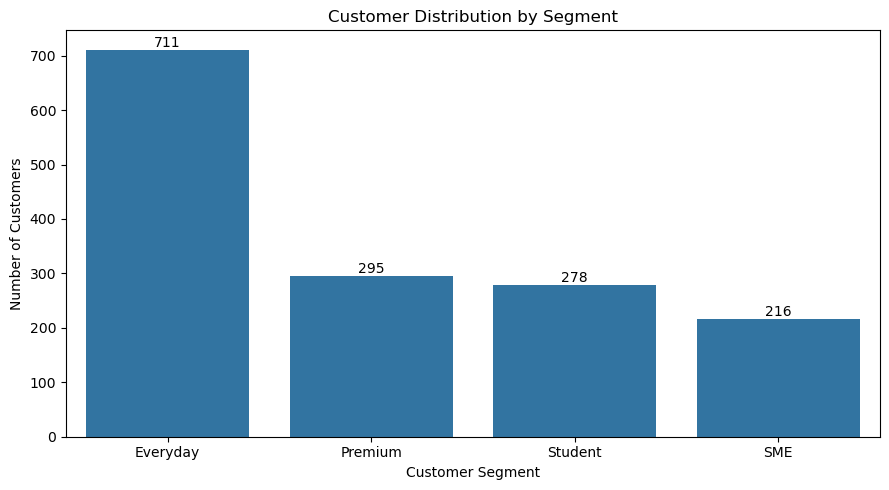

In [9]:
# Visualization 1: Customer distribution by segment

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=segment_counts,
    x="Customer_Segment",
    y="Customer_Count"
)

plt.title("Customer Distribution by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

# Add values above each bar
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### Interpretation

**What does the visual show?**  
The chart shows the distribution of FinTrust's 1,500 customers across four customer segments. Everyday customers form the largest segment with 711 customers, followed by Premium (295), Student (278), and SME (216).

**Why is it important?**  
Understanding the size of each customer segment provides context for interpreting transaction activity. A segment with a larger total transaction volume may partly reflect the fact that it contains more customers.

**Business insight:**  
Everyday customers represent the largest customer group in the dataset. FinTrust should therefore consider both absolute transaction activity and per-customer behaviour when comparing segments, rather than assuming that the segment with the highest total activity necessarily has more active individual customers.

## 4. Transaction Type Analysis

### Visualization 2 — Transaction Volume by Type

This analysis examines the frequency of different transaction types to understand the activities most commonly performed by FinTrust customers.

In [10]:
# Count transactions by type
transaction_type_counts = (
    transactions["Transaction_Type"]
    .value_counts()
    .reset_index()
)

transaction_type_counts.columns = [
    "Transaction_Type",
    "Transaction_Count"
]

transaction_type_counts

,Transaction_Type,Transaction_Count
0,Transfer,3549
1,Card Purchase,3033
2,Bill Payment,1475
3,Cash Withdrawal,1430
4,Deposit,1328
5,Airtime/Data,1185


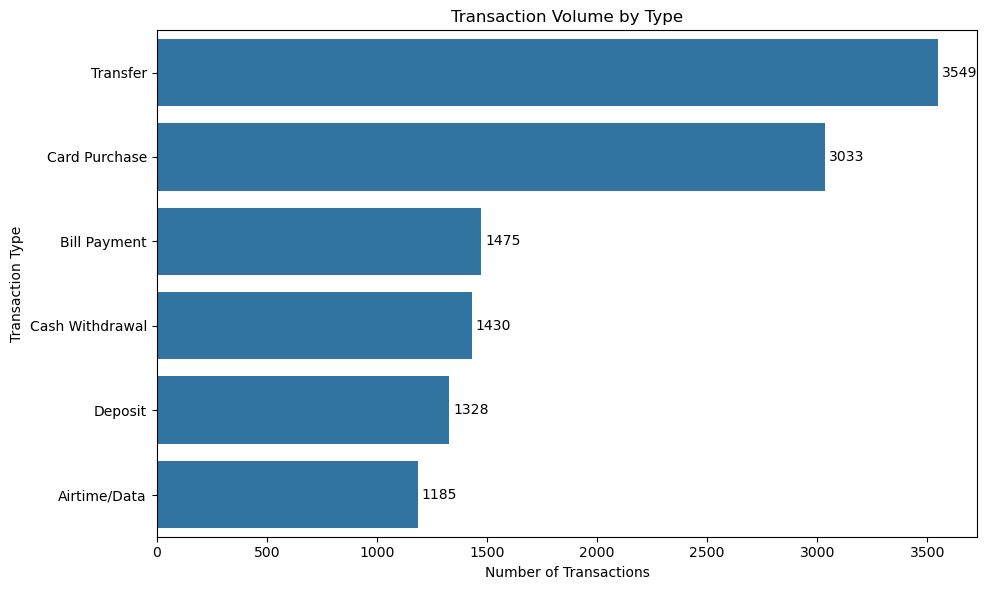

In [11]:
# Visualization 2: Transaction volume by type

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=transaction_type_counts,
    x="Transaction_Count",
    y="Transaction_Type"
)

plt.title("Transaction Volume by Type")
plt.xlabel("Number of Transactions")
plt.ylabel("Transaction Type")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

### Interpretation

**What does the visual show?**  
Transfers are the most frequent transaction type with 3,549 transactions, followed by Card Purchases with 3,033. Airtime/Data transactions have the lowest frequency with 1,185 transactions.

**Why is it important?**  
Transaction frequency helps FinTrust understand which banking services customers use most often. It also provides context for operational planning and for interpreting transaction value across different transaction categories.

**Business insight:**  
Transfers and Card Purchases together account for a substantial share of transaction activity in the dataset, indicating that these are major components of customer transaction behaviour. However, transaction frequency alone does not indicate monetary importance; a less frequent transaction type may involve larger individual transaction amounts. Transaction volume should therefore be considered alongside transaction value.

### Visualization 3 — Transaction Value by Type

Transaction frequency alone does not show the monetary importance of each transaction type. This analysis compares the total and average transaction values across transaction categories.

In [12]:
# Calculate transaction value metrics by type

transaction_value_by_type = (
    transactions
    .groupby("Transaction_Type")
    .agg(
        Transaction_Count=("Transaction_ID", "count"),
        Total_Value_NGN=("Amount_NGN", "sum"),
        Average_Value_NGN=("Amount_NGN", "mean")
    )
    .reset_index()
    .sort_values("Total_Value_NGN", ascending=False)
)

transaction_value_by_type.round(2)

,Transaction_Type,Transaction_Count,Total_Value_NGN,Average_Value_NGN
5,Transfer,3549,2.379167e+08,67037.67
4,Deposit,1328,1.309851e+08,98633.33
2,Card Purchase,3033,8.586341e+07,28309.73
3,Cash Withdrawal,1430,6.777236e+07,47393.26
1,Bill Payment,1475,2.816365e+07,19094.00
0,Airtime/Data,1185,9.776171e+06,8249.93


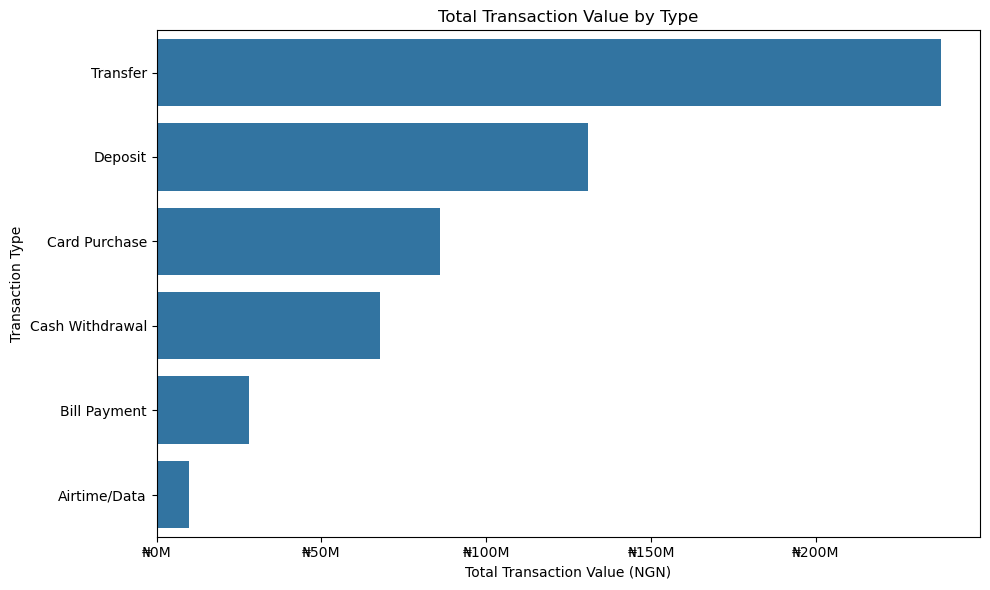

In [13]:
# Visualization 3: Total transaction value by type

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=transaction_value_by_type,
    x="Total_Value_NGN",
    y="Transaction_Type"
)

plt.title("Total Transaction Value by Type")
plt.xlabel("Total Transaction Value (NGN)")
plt.ylabel("Transaction Type")

# Format x-axis values in millions
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f"₦{x/1_000_000:.0f}M")
)

plt.tight_layout()
plt.show()

### Interpretation

**What does the visual show?**  
Transfers generate the highest total transaction value at approximately NGN 237.92 million, followed by Deposits at approximately NGN 130.99 million. Although Deposits occur less frequently than Transfers and Card Purchases, they have the highest average transaction value at approximately NGN 98,633.

**Why is it important?**  
Comparing transaction value with transaction frequency provides a more complete view of customer activity. A transaction category may have relatively low frequency but still represent substantial monetary activity.

**Business insight:**  
Transfers are important in the dataset from both a frequency and monetary-value perspective. Deposits, however, demonstrate a different pattern: they account for fewer transactions but involve substantially larger amounts per transaction. FinTrust should therefore consider both transaction volume and transaction value when evaluating the importance of different banking activities.

## 5. Transaction Channel Analysis

### Visualization 4 — Transaction Volume by Channel

This analysis examines how transaction activity is distributed across FinTrust's available transaction channels.

In [14]:
# Calculate transaction volume by channel

channel_counts = (
    transactions["Channel"]
    .value_counts()
    .reset_index()
)

channel_counts.columns = ["Channel", "Transaction_Count"]

channel_counts

,Channel,Transaction_Count
0,Mobile App,5102
1,POS,2393
2,Web,1869
3,ATM,1747
4,USSD,889


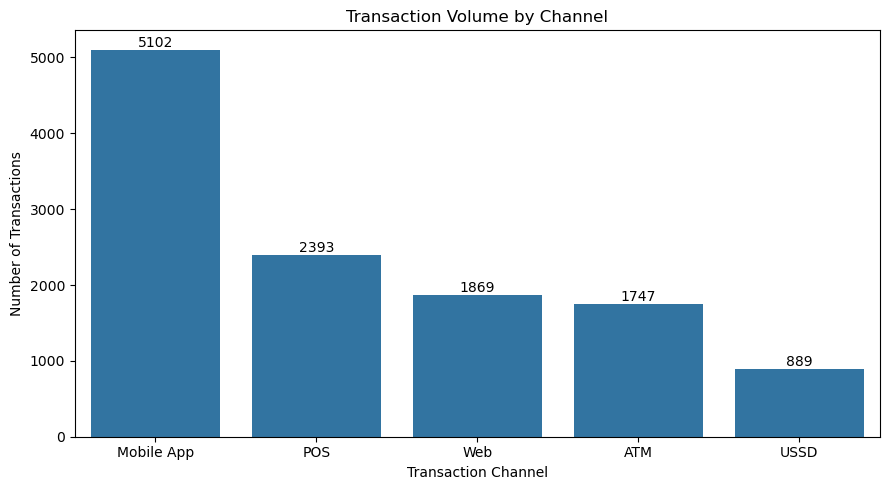

In [15]:
# Visualization 4: Transaction volume by channel

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=channel_counts,
    x="Channel",
    y="Transaction_Count"
)

plt.title("Transaction Volume by Channel")
plt.xlabel("Transaction Channel")
plt.ylabel("Number of Transactions")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### Interpretation

**What does the visual show?**  
The Mobile App is the most frequently used transaction channel, with 5,102 transactions, representing 42.52% of the 12,000 transactions. POS follows with 2,393 transactions, while USSD has the lowest transaction volume with 889 transactions.

**Why is it important?**  
Understanding channel usage helps FinTrust identify where customers conduct most of their transaction activity and provides context for channel capacity, service monitoring, and digital banking behaviour.

**Business insight:**  
The Mobile App accounts for substantially more transaction activity than any other individual channel in the dataset. This indicates strong customer usage of the mobile channel. Because a large share of transaction activity passes through the Mobile App, its performance and reliability are particularly relevant to the customer transaction experience.

## 6. Transaction Status Analysis

### Visualization 5 — Transaction Status Distribution

This analysis examines transaction outcomes to understand the proportion of successful and non-successful transactions in the dataset.

In [16]:
# Calculate transaction status counts and percentages

status_summary = (
    transactions["Transaction_Status"]
    .value_counts()
    .reset_index()
)

status_summary.columns = ["Transaction_Status", "Transaction_Count"]

status_summary["Percentage"] = (
    status_summary["Transaction_Count"] /
    len(transactions) * 100
)

status_summary.round(2)

,Transaction_Status,Transaction_Count,Percentage
0,Successful,10856,90.47
1,Failed,630,5.25
2,Reversed,326,2.72
3,Pending,188,1.57


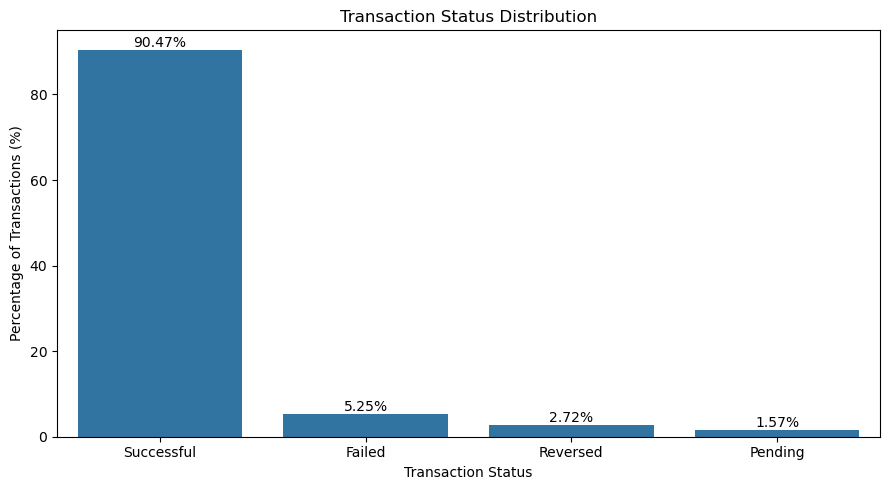

In [17]:
# Visualization 5: Transaction status distribution

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=status_summary,
    x="Transaction_Status",
    y="Percentage"
)

plt.title("Transaction Status Distribution")
plt.xlabel("Transaction Status")
plt.ylabel("Percentage of Transactions (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.tight_layout()
plt.show()

### Interpretation

**What does the visual show?**  
Successful transactions account for 90.47% of all transactions in the dataset. Failed transactions represent 5.25%, reversed transactions 2.72%, and pending transactions 1.57%.

**Why is it important?**  
Transaction status provides insight into transaction outcomes and helps identify the proportion of activity that does not complete successfully.

**Business insight:**  
Successful transactions dominate the dataset. However, 9.53% of transactions are failed, reversed, or pending. Failed transactions form the largest non-successful category, suggesting that they are an important area for further investigation into affected transaction types or channels. Without a FinTrust performance target or benchmark, the observed 90.47% success rate should be treated as a baseline rather than classified as high or low.

## 7. Transaction Trend Analysis

### Visualization 6 — Monthly Transaction Volume

This analysis examines how transaction activity changed across the three-month period covered by the dataset (January to March 2026).

In [18]:
# Calculate monthly transaction activity

monthly_summary = (
    transactions
    .groupby("Month")
    .agg(
        Transaction_Count=("Transaction_ID", "count"),
        Total_Value_NGN=("Amount_NGN", "sum"),
        Average_Value_NGN=("Amount_NGN", "mean")
    )
    .reset_index()
)

monthly_summary.round(2)

,Month,Transaction_Count,Total_Value_NGN,Average_Value_NGN
0,2026-01,4133,1.884894e+08,45605.96
1,2026-02,3734,1.757869e+08,47077.37
2,2026-03,4133,1.962010e+08,47471.82


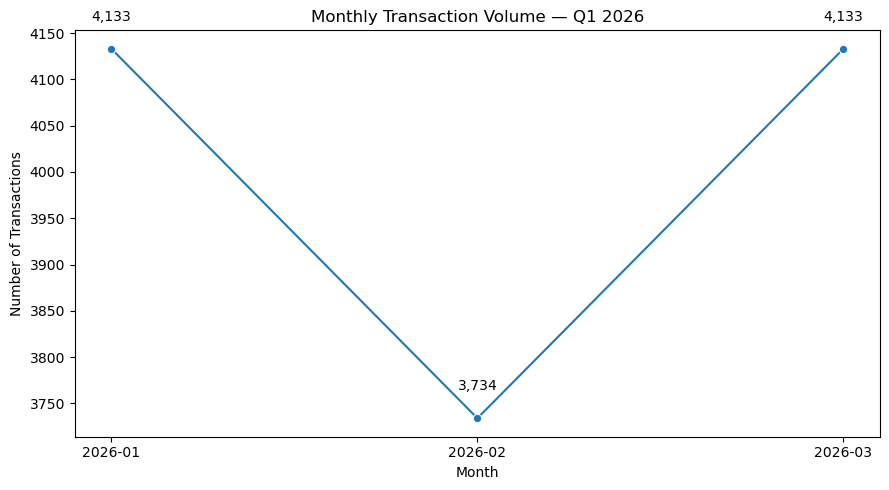

In [19]:
# Visualization 6: Monthly transaction volume

plt.figure(figsize=(9, 5))

ax = sns.lineplot(
    data=monthly_summary,
    x="Month",
    y="Transaction_Count",
    marker="o"
)

plt.title("Monthly Transaction Volume — Q1 2026")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")

# Label each point
for x, y in zip(
    monthly_summary["Month"],
    monthly_summary["Transaction_Count"]
):
    plt.text(x, y + 30, f"{y:,}", ha="center")

plt.tight_layout()
plt.show()

### Interpretation

**What does the visual show?**  
Transaction volume decreased from 4,133 transactions in January to 3,734 in February before returning to 4,133 transactions in March. January and March therefore recorded the same transaction volume, while February had the lowest activity.

**Why is it important?**  
Examining transaction activity over time helps FinTrust identify changes in customer transaction behaviour and provides a baseline for monitoring monthly trends.

**Business insight:**  
Although March recorded the same number of transactions as January, its total transaction value was higher at approximately NGN 196.20 million compared with NGN 188.49 million in January. March also recorded the highest average transaction value at NGN 47,471.82. This indicates that the increase in monetary activity in March was driven by larger transaction values rather than a higher number of transactions.

February recorded both the lowest transaction count and the lowest total transaction value. However, because February has fewer calendar days than January and March, further analysis using daily transaction rates would be useful before concluding that customer activity genuinely declined during February.

## 8. Risk Review Analysis

### Visualization 7 — Risk Review Rate by Transaction Type

This analysis compares the proportion of transactions flagged for risk review across different transaction types.

In [20]:
# Calculate risk-review rate by transaction type

risk_by_type = (
    transactions
    .groupby("Transaction_Type")
    .agg(
        Total_Transactions=("Transaction_ID", "count"),
        Risk_Reviewed=(
            "Risk_Review_Flag",
            lambda x: (x == "Yes").sum()
        )
    )
    .reset_index()
)

risk_by_type["Risk_Review_Rate"] = (
    risk_by_type["Risk_Reviewed"] /
    risk_by_type["Total_Transactions"] * 100
)

risk_by_type = risk_by_type.sort_values(
    "Risk_Review_Rate",
    ascending=False
)

risk_by_type.round(2)

,Transaction_Type,Total_Transactions,Risk_Reviewed,Risk_Review_Rate
5,Transfer,3549,1011,28.49
3,Cash Withdrawal,1430,362,25.31
4,Deposit,1328,215,16.19
0,Airtime/Data,1185,180,15.19
2,Card Purchase,3033,395,13.02
1,Bill Payment,1475,189,12.81


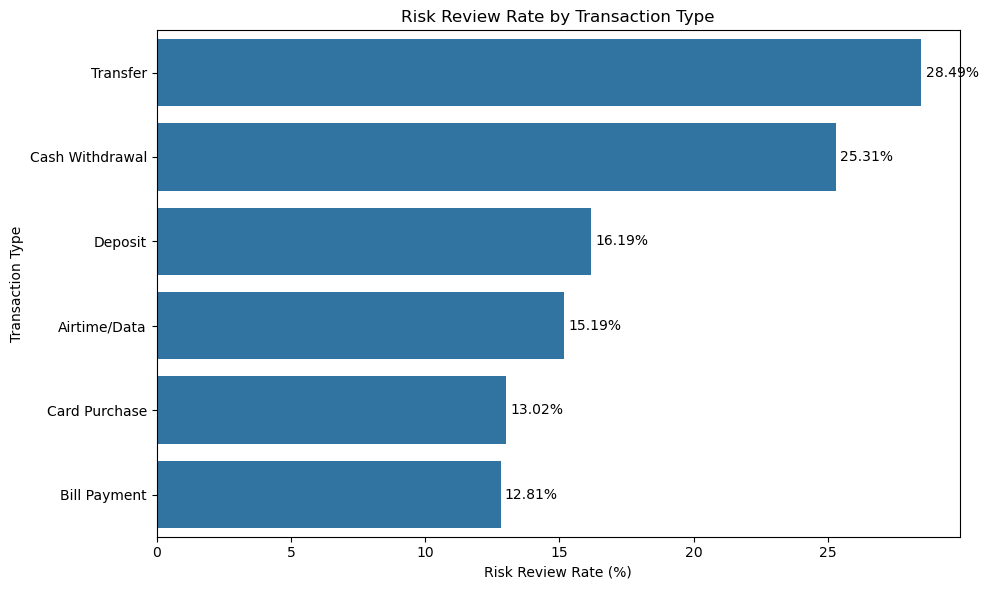

In [21]:
# Visualization 7: Risk-review rate by transaction type

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=risk_by_type,
    x="Risk_Review_Rate",
    y="Transaction_Type"
)

plt.title("Risk Review Rate by Transaction Type")
plt.xlabel("Risk Review Rate (%)")
plt.ylabel("Transaction Type")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)

plt.tight_layout()
plt.show()

### Interpretation

**What does the visual show?**  
Transfers have the highest risk-review rate at 28.49%, followed by Cash Withdrawals at 25.31%. Bill Payments have the lowest risk-review rate at 12.81%.

**Why is it important?**  
Using risk-review rates rather than only the number of reviewed transactions allows transaction types with different transaction volumes to be compared fairly.

**Business insight:**  
Transfers and Cash Withdrawals are selected for risk review more frequently than the other transaction types in the dataset. This suggests that FinTrust could examine the characteristics associated with these transaction categories to better understand the factors driving review activity.

A risk-review flag should not be interpreted as evidence of fraud. It indicates that a transaction was selected for additional review.

## 9. International Transaction Analysis

### Visualization 8 — Risk Review Rate: Domestic vs International Transactions

This analysis compares risk-review rates between domestic and international transactions to determine whether review patterns differ between the two groups.

In [22]:
# Calculate risk-review rate for domestic vs international transactions

international_risk = (
    transactions
    .groupby("International_Transaction")
    .agg(
        Total_Transactions=("Transaction_ID", "count"),
        Risk_Reviewed=(
            "Risk_Review_Flag",
            lambda x: (x == "Yes").sum()
        )
    )
    .reset_index()
)

international_risk["Risk_Review_Rate"] = (
    international_risk["Risk_Reviewed"] /
    international_risk["Total_Transactions"] * 100
)

international_risk.round(2)

,International_Transaction,Total_Transactions,Risk_Reviewed,Risk_Review_Rate
0,No,11520,2175,18.88
1,Yes,480,177,36.88


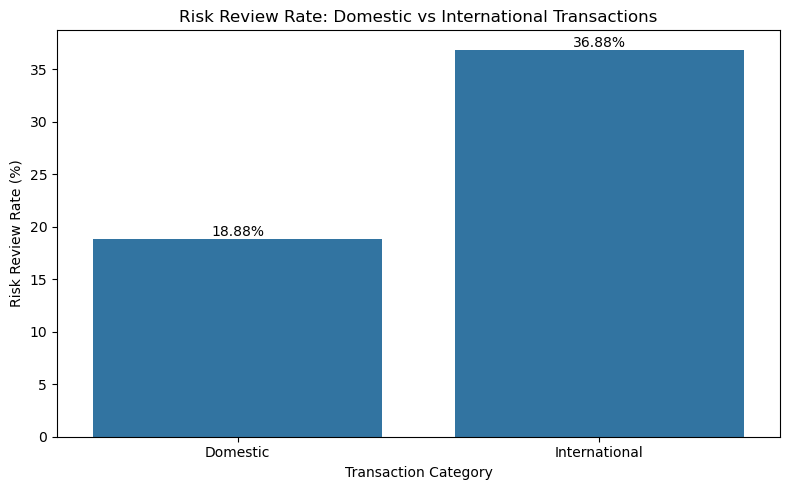

In [23]:
# Improve labels for visualization
international_risk["Transaction_Category"] = (
    international_risk["International_Transaction"]
    .map({
        "No": "Domestic",
        "Yes": "International"
    })
)

# Visualization 8: Risk-review rate for domestic vs international transactions

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=international_risk,
    x="Transaction_Category",
    y="Risk_Review_Rate"
)

plt.title("Risk Review Rate: Domestic vs International Transactions")
plt.xlabel("Transaction Category")
plt.ylabel("Risk Review Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.tight_layout()
plt.show()

### Interpretation

**What does the visual show?**  
International transactions have a risk-review rate of 36.88%, compared with 18.88% for domestic transactions. Of the 480 international transactions, 177 were flagged for risk review, while 2,175 of the 11,520 domestic transactions were flagged.

**Why is it important?**  
Although international transactions represent only 4% of total transaction activity, comparing their risk-review rate with domestic transactions provides insight into how review activity differs between the two transaction categories.

**Business insight:**  
International transactions were flagged for risk review at nearly twice the rate observed for domestic transactions in this dataset. This indicates a strong association between international transaction status and risk-review activity.

For FinTrust, this pattern may warrant further investigation into the criteria or transaction characteristics associated with international activity. However, the analysis does not establish that international transactions are fraudulent or that being international causes a transaction to be flagged; the risk-review flag only indicates that additional review was required.

## 10. Customer Behaviour Analysis

### Customer Transaction Behaviour by Segment

This analysis combines customer and transaction data to compare transaction behaviour across customer segments.

In [24]:
# Merge customer information with transaction data

customer_transactions = transactions.merge(
    customers[
        ["Customer_ID", "Customer_Segment", "Account_Type"]
    ],
    on="Customer_ID",
    how="left"
)

# Summarize transaction behaviour by customer segment

segment_behaviour = (
    customer_transactions
    .groupby("Customer_Segment")
    .agg(
        Customers=("Customer_ID", "nunique"),
        Transaction_Count=("Transaction_ID", "count"),
        Total_Value_NGN=("Amount_NGN", "sum"),
        Average_Value_NGN=("Amount_NGN", "mean")
    )
    .reset_index()
)

segment_behaviour["Transactions_Per_Customer"] = (
    segment_behaviour["Transaction_Count"] /
    segment_behaviour["Customers"]
)

segment_behaviour = segment_behaviour.sort_values(
    "Transactions_Per_Customer",
    ascending=False
)

segment_behaviour.round(2)

,Customer_Segment,Customers,Transaction_Count,Total_Value_NGN,Average_Value_NGN,Transactions_Per_Customer
3,Student,278,2289,1.074759e+08,46953.20,8.23
1,Premium,295,2361,1.077512e+08,45637.95,8.00
0,Everyday,711,5644,2.614589e+08,46325.11,7.94
2,SME,216,1706,8.379137e+07,49115.69,7.90


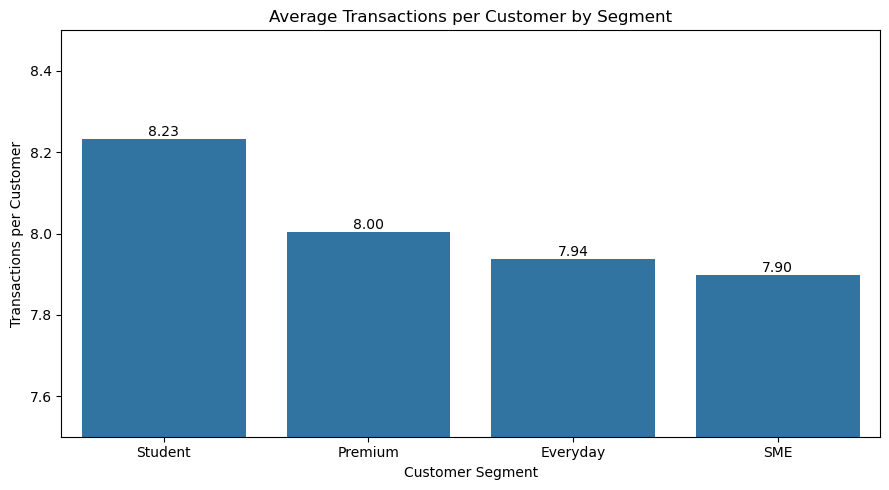

In [25]:
# Visualization 9: Transactions per customer by segment

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=segment_behaviour,
    x="Customer_Segment",
    y="Transactions_Per_Customer"
)

plt.title("Average Transactions per Customer by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Transactions per Customer")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

# Start closer to the observed values so small differences are visible
plt.ylim(7.5, 8.5)

plt.tight_layout()
plt.show()

### Interpretation

**What does the visual show?**  
Student customers recorded the highest transaction frequency at 8.23 transactions per customer, followed by Premium customers at 8.00, Everyday customers at 7.94, and SME customers at 7.90.

**Why is it important?**  
Comparing transactions per customer adjusts for differences in segment size. This provides a fairer comparison than using total transaction counts alone, particularly because the Everyday segment contains substantially more customers than the other segments.

**Business insight:**  
Transaction frequency per customer is relatively similar across all four segments, ranging only from 7.90 to 8.23 transactions per customer. Therefore, the much higher total transaction volume generated by Everyday customers is primarily associated with the larger size of that segment rather than substantially higher transaction frequency per individual customer.

SME customers have the lowest transaction frequency per customer but the highest average transaction value at NGN 49,115.69. This demonstrates that transaction frequency and transaction value provide different perspectives on customer behaviour.

## 11. Key Findings from Exploratory Data Analysis

The exploratory analysis identified the following key patterns:

1. **Customer composition:** Everyday customers form the largest customer segment, with 711 of the 1,500 customers. Segment size therefore needs to be considered when comparing total transaction activity.

2. **Transaction behaviour:** Transfers are the most frequent transaction type with 3,549 transactions and also generate the highest total transaction value at approximately NGN 237.92 million. Deposits occur less frequently but have the highest average transaction value at approximately NGN 98,633.

3. **Channel usage:** The Mobile App is the dominant transaction channel, accounting for 5,102 transactions, or 42.52% of total transaction activity.

4. **Transaction outcomes:** 90.47% of transactions are successful. The remaining 9.53% are failed, reversed, or pending, with failed transactions forming the largest non-successful category.

5. **Monthly activity:** Transaction volume decreased from 4,133 in January to 3,734 in February before returning to 4,133 in March. March generated the highest total and average transaction values. February's lower raw volume should be interpreted with consideration of its fewer calendar days.

6. **Risk-review patterns:** Transfers have the highest risk-review rate at 28.49%, followed by Cash Withdrawals at 25.31%. These categories are therefore more frequently selected for review within the dataset.

7. **International transactions:** International transactions represent only 4% of total transaction activity but have a 36.88% risk-review rate compared with 18.88% for domestic transactions. This indicates an association between international transaction status and risk-review activity, but does not establish fraud or causation.

8. **Customer segment behaviour:** Transactions per customer are relatively consistent across customer segments, ranging from 7.90 to 8.23. SME customers have the highest average transaction value despite having the lowest transaction frequency per customer.